## CMPINF 2100 Week 07

### Review: Point Plots


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Read data
We will continue to work with GAP MINDER data set

In [2]:
gap_url = 'https://raw.githubusercontent.com/chendaniely/pandas_for_everyone/master/data/gapminder.tsv'

In [5]:
gap_df = pd.read_csv( gap_url, sep = '\t')

In [6]:
gap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


## Point Plot
The point Plot shows or visualize the **CONDITIONAL MEAN** of a continuous variable **GIVEN** a CATEGORICAL variable.
I.e. it is a CATEGORICAL to CONDINUOUS relationship plot.
In Seaborn it is part of the 'sns.catplot()' FIGURE LEVEL function family because it is FOCUSED on categorical groupings!

Usually the categorical variable is associated with the 'x' axis and the continuoous variable is associated withe the 'y' axis.

The CONDITIONAL MEAN of lifeExp GIVEN the year

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


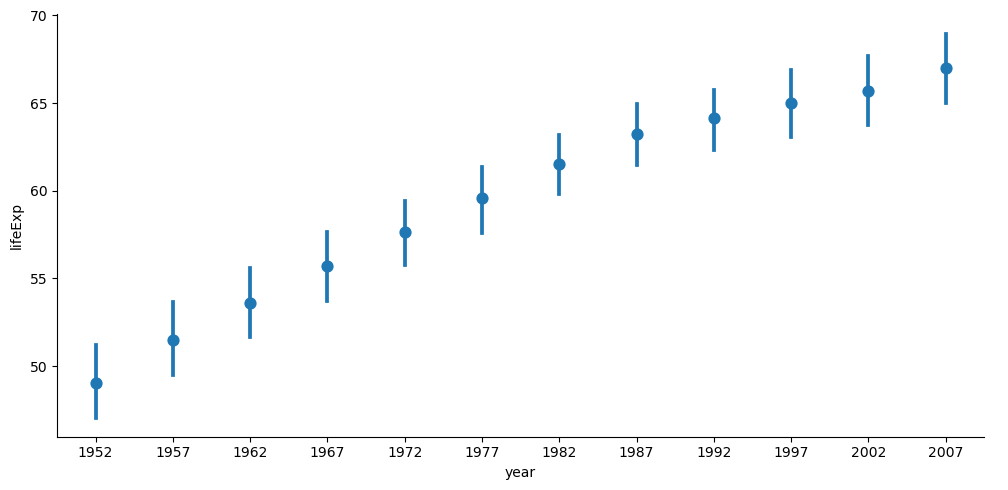

In [9]:
sns.catplot( data = gap_df, x='year', y='lifeExp', kind='point', aspect=2, linestyle='none')
plt.show()

We could have grouped by continent variable

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


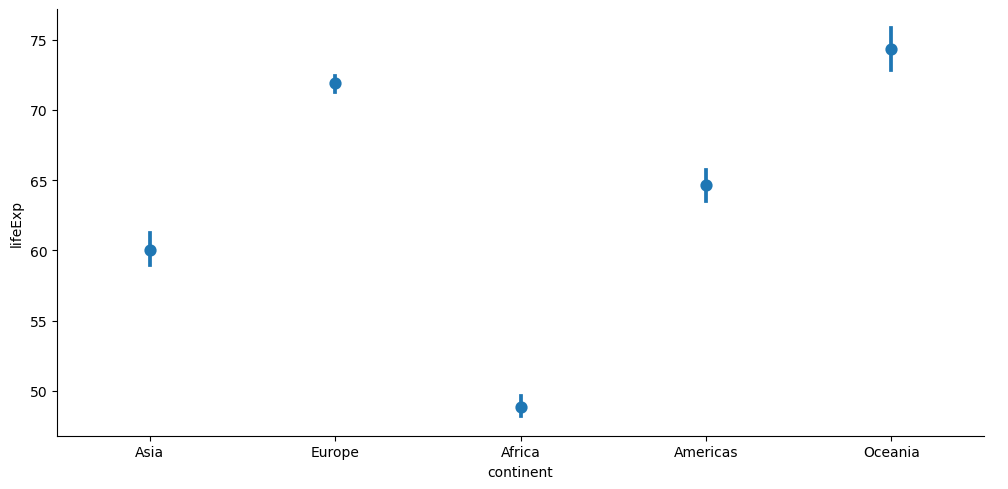

In [12]:
sns.catplot( data = gap_df, x='continent', y='lifeExp', kind='point', aspect=2, linestyle='none')
plt.show()

We could also GROUP by 2 categorical variables!!!

One or the PRIMARY categorical variable is associated with the 'x' axis while the SECONDARY categorical variable is associated with the marker 'hue' or color

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


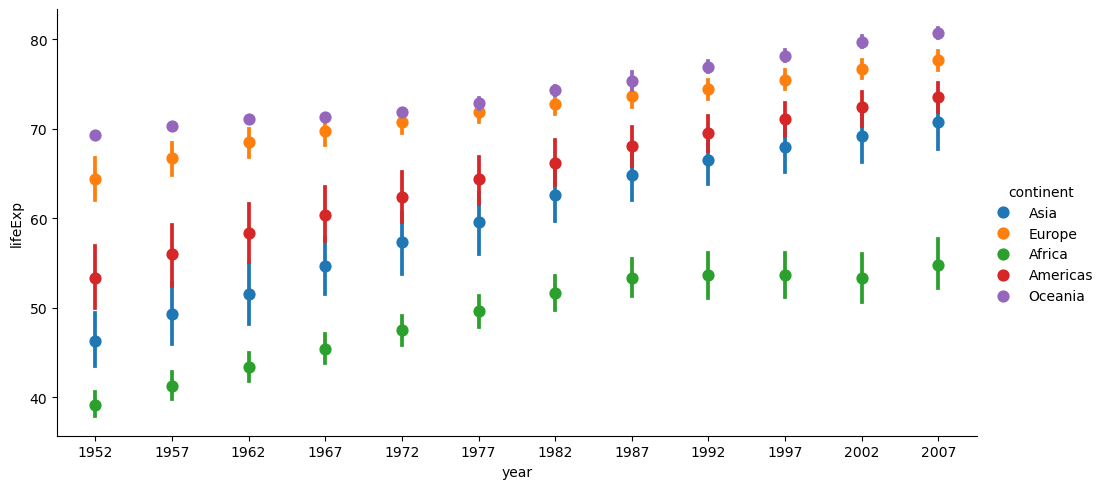

In [13]:
sns.catplot( data = gap_df, x='year', y='lifeExp', hue='continent', kind='point', aspect=2, linestyle='none' )
plt.show()

## What is the vertical line?
The vertical line is an ERROR BAR

The ERROR BAR is showing us by default the 95% CONFIDENCE INTERVAL on the AVERAGE!!!

The CONFIDENCE INTERVAL is sometimes denoted as CI

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


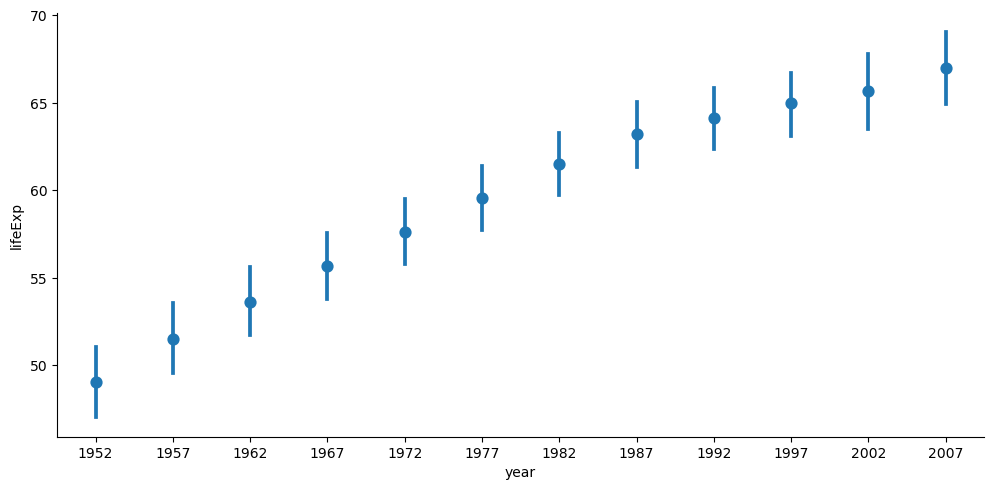

In [14]:
sns.catplot( data = gp_df, x='year', y='lifeExp', kind='point', aspect=2, linestyle='none',
            errorbar=('ci', 95))
plt.show()

changing confidence interval (ci) to 68

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


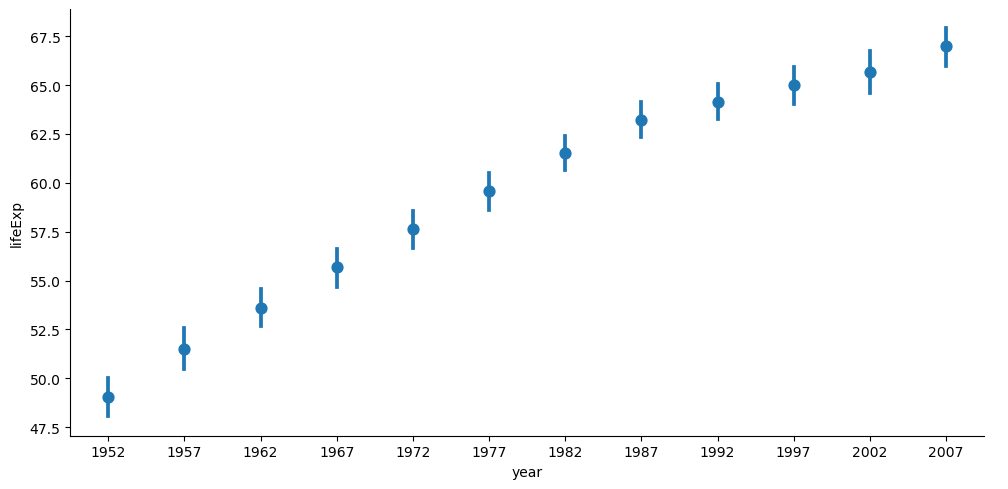

In [15]:
sns.catplot( data = gp_df, x='year', y='lifeExp', kind='point', aspect=2, linestyle='none',
            errorbar=('ci', 68))
plt.show()

But what is the CI? and HOW is CI calculated?

The CI comes from the SEM!!!

The confidence interval is a MULTIPLE of the SEM AROUND the AVERAGE!!!

Begin by GROUPING BY the categorical and SUMMARIZING the continuous!!!

In [17]:
gap_df.groupby(['year']).\
aggregate(lifeExp_count = ('lifeExp', 'count'),
         lifeExp_avg = ('lifeExp', 'mean'),
         lifeExp_sem = ('lifeExp', 'sem')).\
reset_index()

,year,lifeExp_count,lifeExp_avg,lifeExp_sem
0,1952,142,49.057620,1.025979
1,1957,142,51.507401,1.026427
2,1962,142,53.609249,1.015178
3,1967,142,55.678290,0.983425
4,1972,142,57.647386,0.955152
5,1977,142,59.570157,0.942168
6,1982,142,61.533197,0.903850
7,1987,142,63.212613,0.885864
8,1992,142,64.160338,0.942181
9,1997,142,65.014676,0.970047


Let's assign our GROOUPED and SUMMARIZED DataFrame to an object

In [18]:
gap_year_summary = gap_df.groupby(['year']).\
aggregate(lifeExp_count = ('lifeExp', 'count'),
         lifeExp_avg = ('lifeExp', 'mean'),
         lifeExp_sem = ('lifeExp', 'sem')).\
reset_index()

In [19]:
gap_year_summary

,year,lifeExp_count,lifeExp_avg,lifeExp_sem
0,1952,142,49.057620,1.025979
1,1957,142,51.507401,1.026427
2,1962,142,53.609249,1.015178
3,1967,142,55.678290,0.983425
4,1972,142,57.647386,0.955152
5,1977,142,59.570157,0.942168
6,1982,142,61.533197,0.903850
7,1987,142,63.212613,0.885864
8,1992,142,64.160338,0.942181
9,1997,142,65.014676,0.970047


Let's calculate the 95% CI using the CONDITIONAL MEANS and their respective SEM

The LOWER BOUND on the 95% CI is the MEAN MINUS 2 TIMES the SEM

The UPPER BOUND on the 95% CI is the MEAN PLUS 2 TIMES the SEM

These formulas come from the fact that the distribution on the MEAN is a GAUSSIAN according to the Central Limit Theorem

In [22]:
gap_year_summary['lifeExp_ci_lwr'] = gap_year_summary.lifeExp_avg - 2 * gap_year_summary.lifeExp_sem

gap_year_summary['lifeExp_ci_upr'] = gap_year_summary.lifeExp_avg + 2 * gap_year_summary.lifeExp_sem

In [23]:
gap_year_summary

,year,lifeExp_count,lifeExp_avg,lifeExp_sem,lifeExp_ci_lwr,lifeExp_ci_upr
0,1952,142,49.057620,1.025979,47.005661,51.109579
1,1957,142,51.507401,1.026427,49.454548,53.560255
2,1962,142,53.609249,1.015178,51.578893,55.639606
3,1967,142,55.678290,0.983425,53.711440,57.645139
4,1972,142,57.647386,0.955152,55.737082,59.557691
5,1977,142,59.570157,0.942168,57.685821,61.454494
6,1982,142,61.533197,0.903850,59.725497,63.340898
7,1987,142,63.212613,0.885864,61.440885,64.984340
8,1992,142,64.160338,0.942181,62.275977,66.044700
9,1997,142,65.014676,0.970047,63.074583,66.954769


Return to POINT PLOT

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


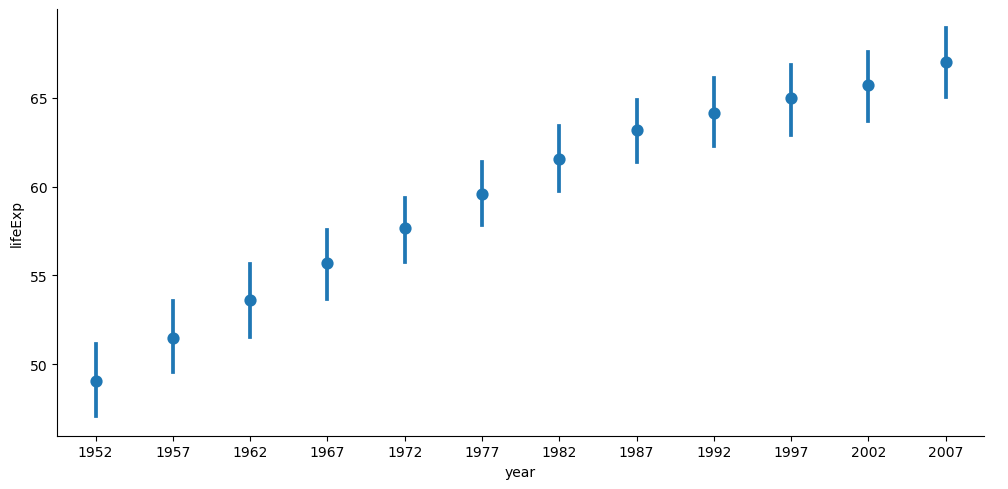

In [24]:
sns.catplot( data = gap_df, x='year', y='lifeExp', kind='point', aspect=2, linestyle='none')
plt.show()

Use the AXIS LEVEL function for greate control

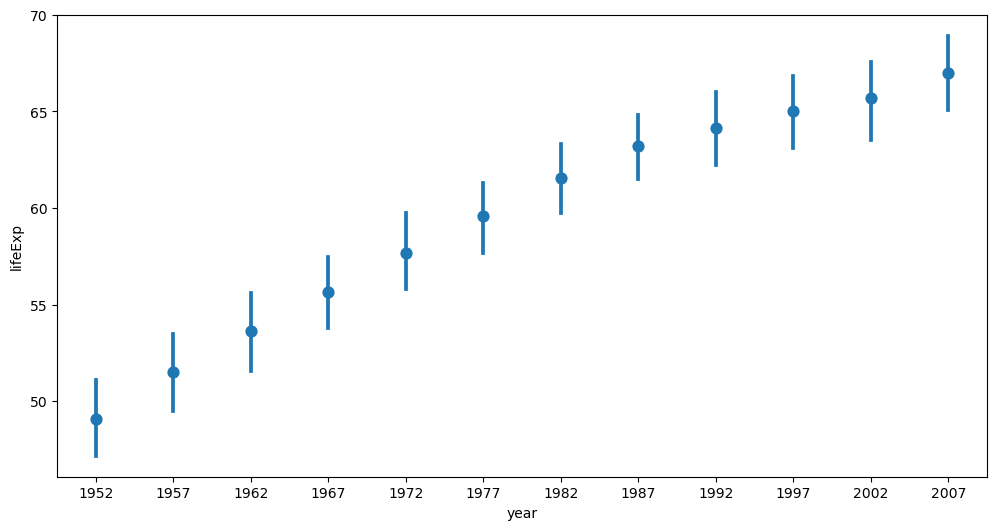

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.pointplot( data = gap_df, x='year', y='lifeExp', linestyle='none', ax=ax)
plt.show()

In [27]:
ax.get_xlim()

(-0.5, 11.5)

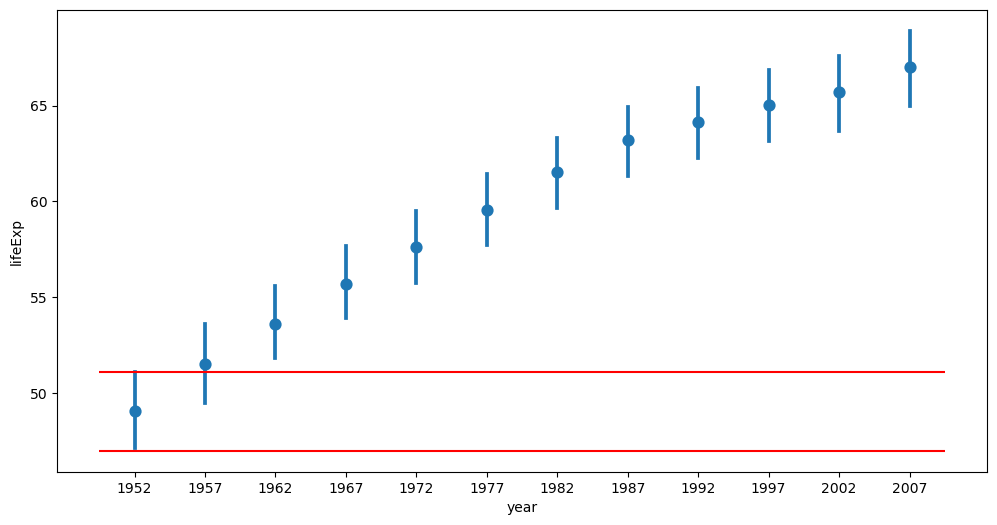

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.pointplot( data = gap_df, x='year', y='lifeExp', linestyle='none', ax=ax)
ax.hlines(y=[47, 51.1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='r')
plt.show()

In [29]:
gap_year_summary

,year,lifeExp_count,lifeExp_avg,lifeExp_sem,lifeExp_ci_lwr,lifeExp_ci_upr
0,1952,142,49.057620,1.025979,47.005661,51.109579
1,1957,142,51.507401,1.026427,49.454548,53.560255
2,1962,142,53.609249,1.015178,51.578893,55.639606
3,1967,142,55.678290,0.983425,53.711440,57.645139
4,1972,142,57.647386,0.955152,55.737082,59.557691
5,1977,142,59.570157,0.942168,57.685821,61.454494
6,1982,142,61.533197,0.903850,59.725497,63.340898
7,1987,142,63.212613,0.885864,61.440885,64.984340
8,1992,142,64.160338,0.942181,62.275977,66.044700
9,1997,142,65.014676,0.970047,63.074583,66.954769


In summary... the POINT PLOT performs the FOLLOWING actions for us:
* Calculates the CONDITIONAL MEAN (AVERAGE) for the y-axis variable GIVEN each x-axis CATEGORY
* Calculates the SEM for the y-axis variable GIVEN each x-axis CATEGORY
* Calculates the LOWER BOUND on the CI
* Calculates the UPPER BOUND on the CI
* Plots the CONDITIONAL MEAN as a POINT (dot)
* Plots the CI as an ERROR BAR between the LOWER and UPPER bounds

In other words the POINT PLOT saves a lot of time when visually exploring data!!!

Let's see what we would need to do inorder make th plot manually using Pandas plotting methods

We need to do some data manipulation...

In [34]:
gap_year_summary.set_index('year')

,lifeExp_count,lifeExp_avg,lifeExp_sem,lifeExp_ci_lwr,lifeExp_ci_upr
year,,,,,
1952,142,49.057620,1.025979,47.005661,51.109579
1957,142,51.507401,1.026427,49.454548,53.560255
1962,142,53.609249,1.015178,51.578893,55.639606
1967,142,55.678290,0.983425,53.711440,57.645139
1972,142,57.647386,0.955152,55.737082,59.557691
1977,142,59.570157,0.942168,57.685821,61.454494
1982,142,61.533197,0.903850,59.725497,63.340898
1987,142,63.212613,0.885864,61.440885,64.984340
1992,142,64.160338,0.942181,62.275977,66.044700


In [35]:
gap_year_summary.loc[:, ['year', 'lifeExp_ci_lwr', 'lifeExp_avg', 'lifeExp_ci_upr']].set_index('year')

,lifeExp_ci_lwr,lifeExp_avg,lifeExp_ci_upr
year,,,
1952,47.005661,49.057620,51.109579
1957,49.454548,51.507401,53.560255
1962,51.578893,53.609249,55.639606
1967,53.711440,55.678290,57.645139
1972,55.737082,57.647386,59.557691
1977,57.685821,59.570157,61.454494
1982,59.725497,61.533197,63.340898
1987,61.440885,63.212613,64.984340
1992,62.275977,64.160338,66.044700


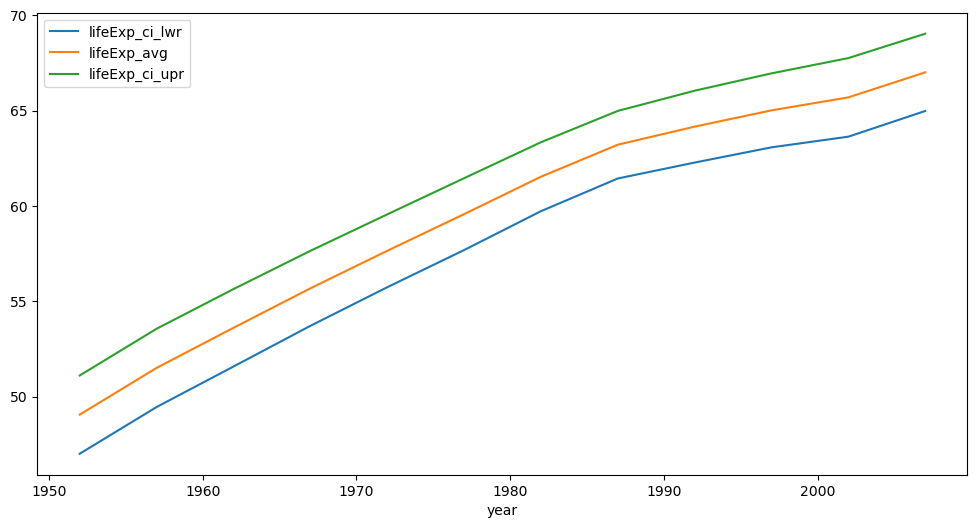

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))

gap_year_summary.loc[:, ['year', 'lifeExp_ci_lwr', 'lifeExp_avg', 'lifeExp_ci_upr']].set_index('year').\
plot(ax=ax)
plt.show()